## Fine-Tuning Llama 3.2 1B — Automotive Comparison Tool

In [1]:
!pip install -q -U \
    "transformers>=4.45.0" \
    "peft>=0.13.0" \
    "bitsandbytes>=0.43.0" \
    "datasets>=3.0.0" \
    "trl>=0.12.0" \
    "accelerate>=1.0.0"

!pip install --upgrade "torchao>0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 91.6 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 75.5 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have num

In [2]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

MODEL_ID     = "meta-llama/Llama-3.2-1B-Instruct"
DATASET_PATH = "/kaggle/working/automotive_dataset_final.jsonl"
OUTPUT_DIR   = "/kaggle/working/llama32_automotive"
MERGED_DIR   = "/kaggle/working/llama32_automotive_merged"

N_EPOCHS = 5
LR       = 2e-4
LORA_R   = 16

In [3]:
import torch
import json
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, SFTConfig

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


### Login HuggingFace

Richiede un secret `HF_TOKEN` in Kaggle con accesso alla licenza di `meta-llama/Llama-3.2-1B-Instruct`.

In [4]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
login(token=secrets.get_secret("HF_TOKEN"))

### Dataset

In [5]:
# Merge dei dataset generati

import json

files = [
    "/kaggle/input/datasets/giovannicontarino/datasets-traning/dataset_01.jsonl",          # il tuo originale (già fixato)
    "/kaggle/input/datasets/giovannicontarino/datasets-traning/dataset_02.jsonl",
    "/kaggle/input/datasets/giovannicontarino/datasets-traning/dataset_03.jsonl",
    "/kaggle/input/datasets/giovannicontarino/datasets-traning/dataset_04.jsonl",
    "/kaggle/input/datasets/giovannicontarino/datasets-traning/dataset_05.jsonl",
    "/kaggle/input/datasets/giovannicontarino/datasets-traning/dataset_06.jsonl",
    "/kaggle/input/datasets/giovannicontarino/datasets-traning/dataset_07.jsonl",
]

all_examples = []
for f in files:
    with open(f, "r", encoding="utf-8") as fp:
        for line in fp:
            if line.strip():
                all_examples.append(json.loads(line.strip()))

with open("automotive_dataset_final.jsonl", "w", encoding="utf-8") as fp:
    for ex in all_examples:
        fp.write(json.dumps(ex, ensure_ascii=False) + "\n")

print(f"Dataset finale: {len(all_examples)} esempi")

Dataset finale: 150 esempi


In [6]:
# Verifica integrita del file JSONL
errors = []
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        try:
            obj = json.loads(line.strip())
            roles = [m["role"] for m in obj["messages"]]
            assert roles == ["system", "user", "assistant"]
        except Exception as e:
            errors.append((i + 1, str(e)))

print(f"Errori: {len(errors)}" if errors else "Dataset valido")
for line_num, err in errors:
    print(f"  Riga {line_num}: {err}")

Dataset valido


In [7]:
dataset_full = load_dataset("json", data_files=DATASET_PATH, split="train")  # ← aggiunta
dataset = dataset_full.train_test_split(test_size=0.1, seed=42)
train_dataset = dataset["train"]
eval_dataset  = dataset["test"]
print(f"Totale : {len(dataset_full)}")
print(f"Train  : {len(train_dataset)} | Eval: {len(eval_dataset)}")

Generating train split: 0 examples [00:00, ? examples/s]

Totale : 150
Train  : 135 | Eval: 15


### Analisi del Dataset

Prima di addestrare, visualizziamo la composizione del dataset: distribuzione auto/moto, esiti per categoria e lunghezza delle risposte. Questo verifica il bilanciamento dei dati.

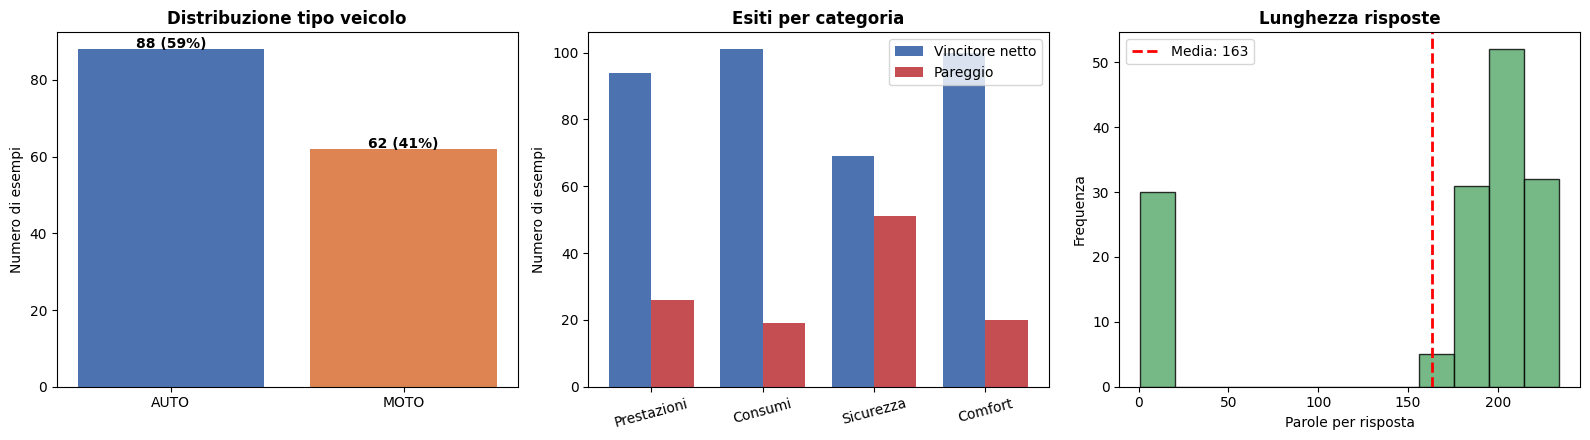

Totale esempi  : 150
  Train        : 135
  Eval         : 15
AUTO           : 88 | MOTO: 62
Pareggi totali : 116/480


In [8]:
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

MOTO_KW = ["ducati","yamaha","kawasaki","ktm","aprilia","triumph","harley","suzuki gsx",
           "honda cbr","honda cb","honda x-adv","honda sh","bmw s 1000","bmw r ","bmw gs",
           "bmw f ","bmw c ","tenere","ténéré","panigale","ninja","tracer","multistrada",
           "moto guzzi","royal enfield","mv agusta","husqvarna","tmax","x-adv","mt-07",
           "mt-09","z900","z1000","gsx-r","speed triple","tiger","scrambler","monster",
           "vespa","v-strom","versys","tuareg","duke","bonneville","v7"]

cat_names = ["Prestazioni", "Consumi", "Sicurezza", "Comfort"]
tipi, lengths = [], []
cat_pareggi = {c: 0 for c in cat_names}
cat_netti   = {c: 0 for c in cat_names}

for ex in dataset_full:
    user = ex["messages"][1]["content"].lower()
    resp = ex["messages"][2]["content"]
    tipi.append("MOTO" if any(k in user for k in MOTO_KW) else "AUTO")
    lengths.append(len(resp.split()))
    for idx, w in enumerate(re.findall(r"Vincitore:\s*(.+)", resp)[:4]):
        if "pareggio" in w.lower():
            cat_pareggi[cat_names[idx]] += 1
        else:
            cat_netti[cat_names[idx]] += 1

tc = Counter(tipi)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].bar(tc.keys(), tc.values(), color=["#4C72B0", "#DD8452"])
axes[0].set_title("Distribuzione tipo veicolo", fontweight="bold")
axes[0].set_ylabel("Numero di esempi")
for i, (k, v) in enumerate(tc.items()):
    axes[0].text(i, v + 0.3, f"{v} ({100*v/sum(tc.values()):.0f}%)", ha="center", fontweight="bold")

x = np.arange(len(cat_names))
w = 0.38
axes[1].bar(x - w/2, [cat_netti[c]   for c in cat_names], w, label="Vincitore netto", color="#4C72B0")
axes[1].bar(x + w/2, [cat_pareggi[c] for c in cat_names], w, label="Pareggio",        color="#C44E52")
axes[1].set_title("Esiti per categoria", fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(cat_names, rotation=15)
axes[1].set_ylabel("Numero di esempi")
axes[1].legend()

axes[2].hist(lengths, bins=12, color="#55A868", edgecolor="black", alpha=0.8)
axes[2].axvline(np.mean(lengths), color="red", linestyle="--", linewidth=2,
                label=f"Media: {np.mean(lengths):.0f}")
axes[2].set_title("Lunghezza risposte", fontweight="bold")
axes[2].set_xlabel("Parole per risposta")
axes[2].set_ylabel("Frequenza")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Totale esempi  : {len(dataset_full)}")
print(f"  Train        : {len(train_dataset)}")
print(f"  Eval         : {len(eval_dataset)}")
print(f"AUTO           : {tc.get('AUTO', 0)} | MOTO: {tc.get('MOTO', 0)}")
print(f"Pareggi totali : {sum(cat_pareggi.values())}/{sum(cat_pareggi.values()) + sum(cat_netti.values())}")

### Tokenizer e Modello (QLoRA 4-bit)

In [9]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

In [10]:
# Nota: Llama 3.2 usa padding_side="right" con SFTTrainer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "right"
tokenizer.model_max_length = 2048

print(f"Vocabolario : {tokenizer.vocab_size:,}")
print(f"Pad token   : '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Vocabolario : 128,000
Pad token   : '<|eot_id|>' (id=128009)


In [11]:
# attn_implementation="sdpa": Scaled Dot-Product Attention, piu veloce di "eager" su Llama 3.2
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.bfloat16,
    attn_implementation="sdpa"
)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

### LoRA

In [12]:
# target_modules: Llama 3.2 usa proiezioni separate (q/k/v),
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_R * 2,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"]
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 11,272,192 || all params: 1,247,086,592 || trainable%: 0.9039


### Training

In [13]:
training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=N_EPOCHS,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=LR,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    optim="paged_adamw_8bit",
    fp16=False,
    bf16=True,
    gradient_checkpointing=True,
    eval_strategy="epoch",
    logging_strategy="steps",
    logging_steps=5,        # log frequente per una curva di loss leggibile
    save_strategy="epoch",
    save_total_limit=2,
    report_to="none",
    dataset_text_field=None  # SFTTrainer rileva automaticamente il campo "messages"
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [14]:
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    args=training_args
    # SFTTrainer applica automaticamente il chat template di Llama 3.2
    # e calcola la loss solo sui token dell'assistente
)

train_result = trainer.train()
print(f"Loss finale: {train_result.training_loss:.4f}")

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

Tokenizing train dataset:   0%|          | 0/135 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/15 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,2.285011,1.391146,1.472431,92756.000000,0.729728
2,1.179177,1.103350,1.138493,185512.000000,0.781343
3,0.954972,1.027497,1.092987,278268.000000,0.792310
4,0.889008,1.004018,1.005000,371024.000000,0.796921
5,0.847498,1.000328,1.011655,463780.000000,0.798042


Loss finale: 1.1696


('/kaggle/working/llama32_automotive/tokenizer_config.json',
 '/kaggle/working/llama32_automotive/chat_template.jinja',
 '/kaggle/working/llama32_automotive/tokenizer.json')

### Curva di Loss del Training

La loss di training mostra se il modello sta imparando. Una curva che scende e poi si appiattisce indica convergenza; una loss che risale segnalerebbe overfitting.

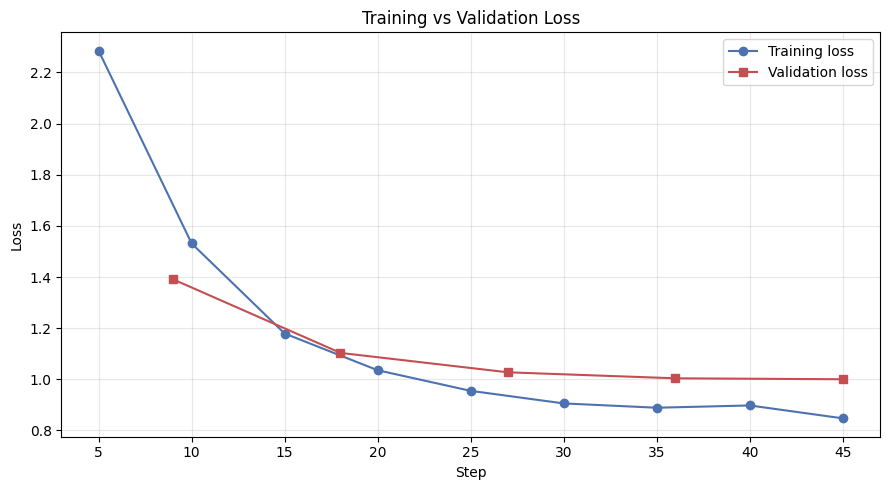

Training loss iniziale: 2.2850
Training loss finale:   0.8475
Validation loss finale: 1.0003


In [15]:
history = trainer.state.log_history
steps  = [h["step"] for h in history if "loss" in h]
losses = [h["loss"] for h in history if "loss" in h]
eval_epochs = [h["epoch"] for h in history if "eval_loss" in h]
eval_losses = [h["eval_loss"] for h in history if "eval_loss" in h]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(steps, losses, marker="o", label="Training loss", color="#4C72B0")
# Mappa le epoche sugli step corrispondenti per sovrapporre la eval loss
steps_per_epoch = max(steps) / N_EPOCHS
eval_steps = [int(e * steps_per_epoch) for e in eval_epochs]
ax.plot(eval_steps, eval_losses, marker="s", label="Validation loss", color="#C44E52")
ax.set_title("Training vs Validation Loss")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(f"Training loss iniziale: {losses[0]:.4f}" if losses else "Nessun log")
print(f"Training loss finale:   {losses[-1]:.4f}" if losses else "")
if eval_losses:
    print(f"Validation loss finale: {eval_losses[-1]:.4f}")

### Efficienza di LoRA: Parametri Allenabili

LoRA addestra solo una piccola frazione dei parametri totali. Questo grafico quantifica il risparmio rispetto al full fine-tuning, in cui si aggiornerebbe il 100% dei pesi.

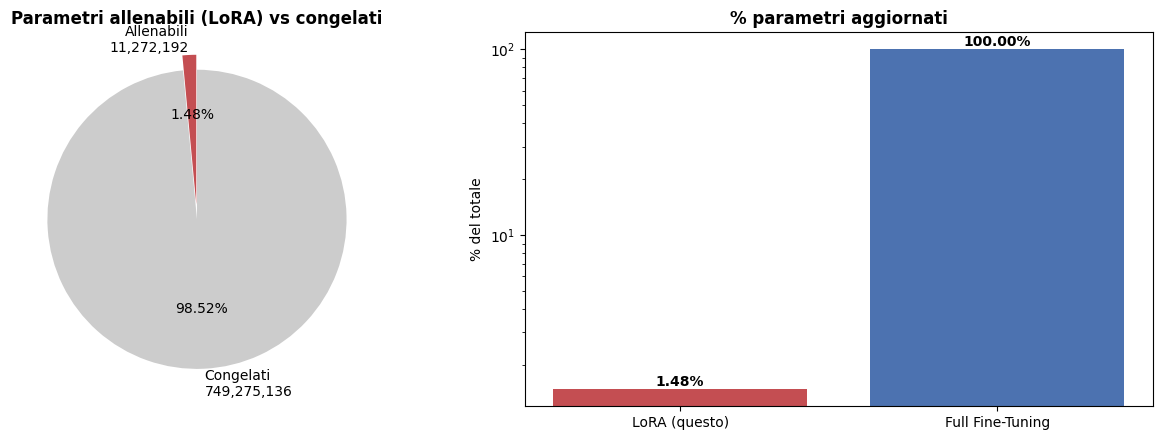

Parametri totali     : 760,547,328
Parametri allenabili : 11,272,192 (1.48%)


In [16]:
import matplotlib.pyplot as plt

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
frozen    = total - trainable

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Torta: allenabili vs congelati
axes[0].pie([trainable, frozen],
            labels=[f"Allenabili\n{trainable:,}", f"Congelati\n{frozen:,}"],
            colors=["#C44E52", "#CCCCCC"], autopct="%1.2f%%", startangle=90,
            explode=(0.1, 0))
axes[0].set_title("Parametri allenabili (LoRA) vs congelati", fontweight="bold")

# Confronto LoRA vs full fine-tuning ipotetico
methods = ["LoRA (questo)", "Full Fine-Tuning"]
percents = [100 * trainable / total, 100.0]
bars = axes[1].bar(methods, percents, color=["#C44E52", "#4C72B0"])
axes[1].set_title("% parametri aggiornati", fontweight="bold")
axes[1].set_ylabel("% del totale")
axes[1].set_yscale("log")
for bar, pct in zip(bars, percents):
    axes[1].text(bar.get_x() + bar.get_width()/2, pct, f"{pct:.2f}%",
                 ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Parametri totali     : {total:,}")
print(f"Parametri allenabili : {trainable:,} ({100*trainable/total:.2f}%)")

### Backup

In [ ]:
import shutil, os

zip_path = "/kaggle/working/llama32_automotive_adapter"
shutil.make_archive(zip_path, "zip", OUTPUT_DIR)
print(f"{zip_path}.zip — {os.path.getsize(zip_path + '.zip') / 1e6:.1f} MB")

### A/B Testing — Base vs Fine-Tuned

In [18]:
SYSTEM_PROMPT = (
    "Sei un ingegnere specializzato in comparazioni automobilistiche e motociclistiche. "
    "Il tuo compito e analizzare i profili tecnici di due veicoli e decretare un vincitore "
    "per categorie specifiche, basandoti ESCLUSIVAMENTE sui dati forniti nei tag XML. "
    "Rispondi usando il formato Markdown richiesto."
)

# Prompt di test con veicoli NON presenti nel dataset di training
TEST_PROMPT = """<veicolo_1>
Marca: Volkswagen
Modello: Golf 1.5 eTSI
Dati estratti: Motore 1.5 TSI mild-hybrid da 150 CV. Consumo WLTP 5.9 l/100km. Prezzo base 29.900 EUR. Euro NCAP 5 stelle (2020), Travel Assist di serie dal livello Life. Infotainment MIB3 da 8.25 pollici, Digital Cockpit da 10 pollici, clima bi-zona.
</veicolo_1>

<veicolo_2>
Marca: Mazda
Modello: 3 Skyactiv-G 2.0
Dati estratti: Motore 2.0 benzina da 150 CV. Consumo WLTP 6.4 l/100km. Prezzo base 28.500 EUR. Euro NCAP 5 stelle (2019), i-Activsense parzialmente di serie. Infotainment Mazda Connect da 8.8 pollici con controllo rotativo, Head-Up Display disponibile.
</veicolo_2>

Genera la comparazione seguendo le istruzioni del sistema."""

In [19]:
def generate(model, tokenizer, system, user, max_new_tokens=600, deterministic=False):
    messages = [
        {"role": "system",    "content": system},
        {"role": "user",      "content": user}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=1.0 if deterministic else 0.7,
            do_sample=not deterministic,
            pad_token_id=tokenizer.eos_token_id
        )
    new_tokens = out[0][inputs.input_ids.shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

In [20]:
tokenizer_eval = AutoTokenizer.from_pretrained(MODEL_ID)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa"
)
base_model.config.use_cache = True
base_model.eval()

risposta_base = generate(base_model, tokenizer_eval, SYSTEM_PROMPT, TEST_PROMPT)
print("--- BASE ---")
print(risposta_base)

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


--- BASE ---
Ecco la comparazione dei due veicoli in base ai dati forniti:

**Caratteristiche generali**

| Carro **|**Volkswagen Golf 1.5 eTSI**|**Mazda 3 Skyactiv-G 2.0**|
|-----------|---------------------------|---------------------------|
| **Marca** | Volkswagen | Mazda |
| **Modello** | Golf 1.5 eTSI | 3 Skyactiv-G 2.0 |
| **Tipologia** | Sedan | Sedan |
| **Anno** | 2020 | 2019 |
| **Motore** | 1.5 TSI mild-hybrid | 2.0 benzina |
| **Cilindrata** | 150 CV | 150 CV |
| **Consumo** | 5.9 l/100km | 6.4 l/100km |
| **Prezzo** | 29.900 EUR | 28.500 EUR |

**Efficacia motore**

| Carro **|**Volkswagen Golf 1.5 eTSI**|**Mazda 3 Skyactiv-G 2.0**|
|-----------|---------------------------|---------------------------|
| **Efficienza motore** | 47,3 l/100km | 44,3 l/100km |
| **Peso totale** | 1.375 kg | 1.345 kg |
| **Mileaggio massimo** | 230 km | 320 km |

**Comfort e sicurezza**

| Carro **|**Volkswagen Golf 1.5 eTSI**|**Mazda 3 Skyactiv-G 2.0**|
|-----------|--------------------------

In [21]:
ft_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
ft_model.config.use_cache = True
ft_model.eval()

risposta_ft = generate(ft_model, tokenizer_eval, SYSTEM_PROMPT, TEST_PROMPT, max_new_tokens=800)
print("--- FINE-TUNED ---")
print(risposta_ft)

--- FINE-TUNED ---
### Analisi Comparativa: Volkswagen Golf 1.5 eTSI vs Mazda 3 Skyactiv-G 2.0

### Prestazioni e Motore

Volkswagen Golf 1.5 eTSI: 150 CV e 250 Nm. Consumo medio di 5.9 l/100km. Mazda 3 Skyactiv-G 2.0: 150 CV e 250 Nm. La differenza principale è un puro potenziale, ma la 3 Skyactiv-G è in grado di spingere la propulsore a trazione benzina a un massimo di 250 Nm, offrendo una accelerazione più netta rispetto al mild-hybrid Volkswagen.

### Consumi e Costi Operativi

Volkswagen Golf 1.5 eTSI: Consumo WLTP 5.9 l/100km. Mazda 3 Skyactiv-G 2.0: Consumo WLTP 6.4 l/100km. Il 3 Skyactiv-G risulta più efficiente, ma il Volkswagen offre un prezzo di listino inferiore di 1.500 EUR, rendendo la Volkswagen la better valuta economica per i consumatori che cercano un'efficienza economica.

### Sicurezza e Affidabilità

Volkswagen Golf 1.5 eTSI: Euro NCAP 5 stelle. Mazda 3 Skyactiv-G 2.0: Euro NCAP 5 stelle. La Mazda riceve un certo regalo per i pilota di guida, grazie al controllo i-

### Installazione librerie di valutazione 


In [22]:
!pip install -q evaluate bert_score rouge_score sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.1 MB/s eta 0:00:00


### TEST SET: 10 casi con veicoli NUOVI (non presenti nel dataset di training).

In [23]:
test_set = [
    {
        "input": """<veicolo_1>
Marca: Alfa Romeo
Modello: Giulia 2.2 Turbodiesel
Dati estratti: Motore 2.2 turbodiesel da 210 CV. Consumo medio di 5.5 l/100km. Prezzo da 55.000 EUR. Sicurezza a 5 stelle Euro NCAP con ADAS di base. Infotainment da 8.8 pollici e climatizzatore automatico bizona.
</veicolo_1>
<veicolo_2>
Marca: BMW
Modello: 320d xDrive
Dati estratti: Motore 2.0 turbodiesel mild-hybrid da 190 CV. Consumo medio di 4.8 l/100km. Prezzo da 56.000 EUR. Sicurezza a 5 stelle Euro NCAP con ADAS di livello 2. Display curvo da 14.9 pollici e climatizzatore automatico trizona.
</veicolo_2>
Genera la comparazione seguendo le istruzioni del sistema.""",
        "reference": """### Analisi Comparativa: Alfa Romeo Giulia 2.2 Turbodiesel vs BMW 320d xDrive
 
1. Prestazioni e Motore
Vincitore: Alfa Romeo Giulia 2.2 Turbodiesel
Motivazione: Il propulsore italiano offre 20 CV in più rispetto al motore bavarese, assicurando una maggiore prontezza e dinamismo alla guida.
2. Consumi e Costi Operativi
Vincitore: BMW 320d xDrive
Motivazione: Grazie al sistema mild-hybrid, la BMW registra un consumo nettamente inferiore (4.8 l/100km contro 5.5 l/100km), che compensa il listino iniziale di poco superiore.
3. Sicurezza e Affidabilità
Vincitore: BMW 320d xDrive
Motivazione: Entrambe hanno ottenuto le 5 stelle Euro NCAP, ma la vettura tedesca si impone per l'offerta di ADAS di livello 2, più avanzati rispetto al pacchetto base dell'Alfa Romeo.
4. Comfort e Tecnologia
Vincitore: BMW 320d xDrive
Motivazione: L'immenso display curvo da 14.9 pollici e il climatizzatore trizona offrono un comfort tecnologico e climatico irraggiungibile dal sistema da 8.8 pollici della Giulia.
Verdetto Finale
L'Alfa Romeo Giulia è la berlina perfetta per chi predilige il coinvolgimento alla guida e la pura potenza meccanica. La BMW 320d xDrive è dedicata a chi viaggia spesso in autostrada, privilegiando l'efficienza dei consumi, la sicurezza attiva e la tecnologia di bordo più all'avanguardia.""",
    },
    {
        "input": """<veicolo_1>
Marca: Dacia
Modello: Duster 1.3 TCe
Dati estratti: Motore 1.3 turbo benzina da 150 CV. Consumo medio di 6.2 l/100km. Prezzo da 25.000 EUR. Sicurezza valutata a 3 stelle Euro NCAP con limitati sistemi di assistenza. Infotainment Media Nav da 8 pollici e climatizzatore automatico.
</veicolo_1>
<veicolo_2>
Marca: Suzuki
Modello: Vitara 1.4 Hybrid
Dati estratti: Motore 1.4 mild-hybrid da 129 CV. Consumo medio di 5.4 l/100km. Prezzo da 25.500 EUR. Sicurezza valutata a 5 stelle Euro NCAP con frenata automatica di serie. Infotainment da 7 pollici touch e climatizzatore automatico.
</veicolo_2>
Genera la comparazione seguendo le istruzioni del sistema.""",
        "reference": """### Analisi Comparativa: Dacia Duster 1.3 TCe vs Suzuki Vitara 1.4 Hybrid
 
1. Prestazioni e Motore
Vincitore: Dacia Duster 1.3 TCe
Motivazione: Con 150 CV a disposizione, la Dacia offre una potenza superiore rispetto ai 129 CV della Vitara, garantendo accelerazioni più vivaci.
2. Consumi e Costi Operativi
Vincitore: Suzuki Vitara 1.4 Hybrid
Motivazione: La tecnologia mild-hybrid permette alla Suzuki di abbattere i consumi (5.4 contro 6.2 l/100km), offrendo un risparmio alla pompa che bilancia ampiamente la minima differenza di prezzo iniziale.
3. Sicurezza e Affidabilità
Vincitore: Suzuki Vitara 1.4 Hybrid
Motivazione: La Suzuki stravince grazie alle 5 stelle Euro NCAP e alla dotazione di sicurezza attiva di serie, distaccando nettamente le sole 3 stelle della Dacia.
4. Comfort e Tecnologia
Vincitore: Dacia Duster 1.3 TCe
Motivazione: Il SUV del gruppo Renault offre un display dell'infotainment da 8 pollici, più grande e appagante rispetto a quello da 7 pollici montato sulla rivale.
Verdetto Finale
La Dacia Duster 1.3 TCe è ideale per chi cerca un veicolo robusto con un motore scattante e un sistema multimediale intuitivo e spazioso. La Suzuki Vitara 1.4 Hybrid si rivolge a chi fa della sicurezza e del risparmio di carburante le proprie priorità assolute, accettando qualche cavallo in meno.""",
    },
    {
        "input": """<veicolo_1>
Marca: Volvo
Modello: EX90
Dati estratti: Motori elettrici per un totale di 408 CV. Consumo medio di 20.9 kWh/100km. Prezzo base di 85.000 EUR. Sicurezza a 5 stelle Euro NCAP con innovativo sensore Lidar di serie. Display verticale da 14.5 pollici con Google Automotive e clima quadrizona.
</veicolo_1>
<veicolo_2>
Marca: Kia
Modello: EV9
Dati estratti: Motori elettrici per un totale di 384 CV. Consumo medio di 22.8 kWh/100km. Prezzo base di 81.000 EUR. Sicurezza a 5 stelle Euro NCAP con ADAS completi. Triplo schermo panoramico e climatizzatore multizona.
</veicolo_2>
Genera la comparazione seguendo le istruzioni del sistema.""",
        "reference": """### Analisi Comparativa: Volvo EX90 vs Kia EV9
 
1. Prestazioni e Motore
Vincitore: Volvo EX90
Motivazione: Il SUV svedese eroga 408 CV, superando di 24 CV il powertrain della Kia e offrendo una spinta maggiore per muovere l'imponente mole del veicolo.
2. Consumi e Costi Operativi
Vincitore: Pareggio
Motivazione: Se da un lato la Kia costa 4.000 EUR in meno al momento dell'acquisto, dall'altro la Volvo risulta significativamente più efficiente (20.9 contro 22.8 kWh/100km), pareggiando i costi nel lungo termine.
3. Sicurezza e Affidabilità
Vincitore: Volvo EX90
Motivazione: Pur essendo entrambe al vertice dei crash test europei, la Volvo fa la differenza integrando il sofisticato sensore Lidar di serie, che offre una percezione predittiva dell'ambiente impareggiabile.
4. Comfort e Tecnologia
Vincitore: Pareggio
Motivazione: La Kia affascina con il suo triplo schermo panoramico ad alta tecnologia, mentre la Volvo risponde con un ecosistema Google perfetto sul suo display da 14.5 pollici e un raffinato clima quadrizona.
Verdetto Finale
La Volvo EX90 è il manifesto per chi esige il massimo storico in fatto di sicurezza attiva e passiva senza badare a spese per la propria famiglia. La Kia EV9 è il maxi SUV elettrico per famiglie numerose che vogliono viaggiare circondate da schermi futuristici a un prezzo iniziale più concorrenziale.""",
    },
    {
        "input": """<veicolo_1>
Marca: BMW
Modello: Z4 sDrive20i
Dati estratti: Motore 2.0 turbo benzina da 197 CV. Consumo medio di 7.1 l/100km. Prezzo da 55.000 EUR. Sicurezza elevata grazie ad ADAS attivi di serie (Euro NCAP non testata). Sistema iDrive con display da 10.25 pollici e clima automatico bizona.
</veicolo_1>
<veicolo_2>
Marca: Porsche
Modello: 718 Boxster
Dati estratti: Motore 2.0 boxer turbo da 300 CV. Consumo medio di 8.9 l/100km. Prezzo da 65.000 EUR. Sicurezza basata sulla dinamica del telaio, ADAS disponibili solo come optional. Infotainment PCM da 7 pollici e climatizzatore manuale.
</veicolo_2>
Genera la comparazione seguendo le istruzioni del sistema.""",
        "reference": """### Analisi Comparativa: BMW Z4 sDrive20i vs Porsche 718 Boxster
 
1. Prestazioni e Motore
Vincitore: Porsche 718 Boxster
Motivazione: Il motore boxer Porsche sprigiona ben 300 CV, surclassando i 197 CV della BMW e fornendo prestazioni dinamiche di tutt'altro livello.
2. Consumi e Costi Operativi
Vincitore: BMW Z4 sDrive20i
Motivazione: La Z4 vince a mani basse sul fronte economico, con consumi notevolmente più bassi (7.1 contro 8.9 l/100km) e un listino inferiore di ben 10.000 EUR.
3. Sicurezza e Affidabilità
Vincitore: BMW Z4 sDrive20i
Motivazione: BMW fornisce di serie sistemi ADAS fondamentali per l'uso stradale quotidiano, mentre Porsche li relega alla lista degli optional a pagamento per non appesantire la vettura.
4. Comfort e Tecnologia
Vincitore: BMW Z4 sDrive20i
Motivazione: Lo schermo da 10.25 pollici del sistema iDrive e il clima bizona rendono l'abitacolo della BMW molto più confortevole e moderno rispetto alla plancia con display da 7 pollici della Boxster.
Verdetto Finale
La BMW Z4 è la spider ideale per chi cerca l'open-air quotidiano, godendo di tecnologie moderne e costi di gestione ragionevoli. La Porsche 718 Boxster è la sportiva pura per la domenica, che sacrifica il comfort e l'efficienza in favore di prestazioni esaltanti.""",
    },
    {
        "input": """<veicolo_1>
Marca: Renault
Modello: Twingo E-Tech
Dati estratti: Motore elettrico da 82 CV. Consumo medio di 16.0 kWh/100km. Prezzo da 24.000 EUR. Sicurezza valutata a 4 stelle Euro NCAP. Infotainment Easy Link da 7 pollici e climatizzatore automatico.
</veicolo_1>
<veicolo_2>
Marca: Smart
Modello: EQ fortwo
Dati estratti: Motore elettrico da 82 CV. Consumo medio di 15.7 kWh/100km. Prezzo da 25.000 EUR. Sicurezza valutata a 4 stelle Euro NCAP. Smart Media System da 8 pollici e climatizzatore automatico.
</veicolo_2>
Genera la comparazione seguendo le istruzioni del sistema.""",
        "reference": """### Analisi Comparativa: Renault Twingo E-Tech vs Smart EQ fortwo
 
1. Prestazioni e Motore
Vincitore: Pareggio
Motivazione: Le due citycar sfruttano il medesimo propulsore elettrico da 82 CV, garantendo le stesse prestazioni brillanti negli scatti da semaforo a semaforo in città.
2. Consumi e Costi Operativi
Vincitore: Pareggio
Motivazione: La Smart consuma leggermente meno (15.7 contro 16.0 kWh/100km), ma la Twingo è più conveniente di 1.000 EUR al momento dell'acquisto, bilanciando perfettamente le voci di spesa economica.
3. Sicurezza e Affidabilità
Vincitore: Pareggio
Motivazione: Nessuna delle due vetture si impone sull'altra in questa categoria, avendo entrambe ottenuto un solido punteggio di 4 stelle Euro NCAP.
4. Comfort e Tecnologia
Vincitore: Smart EQ fortwo
Motivazione: Nonostante la parità climatica, la Smart offre uno schermo del sistema multimediale più grande (8 pollici contro 7), che facilita la lettura e la navigazione nel traffico.
Verdetto Finale
La Renault Twingo E-Tech è l'auto elettrica urbana per chi necessita di estrema praticità a quattro posti contenendo il prezzo d'attacco. La Smart EQ fortwo è il veicolo definitivo per chi deve parcheggiare ovunque, sacrificando i posti posteriori per un design iconico e uno schermo migliore.""",
    },
    {
        "input": """<veicolo_1>
Marca: Maserati
Modello: Grecale Folgore
Dati estratti: Due motori elettrici per un totale di 550 CV. Consumo medio di 24.0 kWh/100km. Prezzo da 125.000 EUR. Sicurezza garantita da telaio irrigidito e ADAS di livello 2. Abitacolo di lusso con triplo schermo digitale e clima trizona.
</veicolo_1>
<veicolo_2>
Marca: Porsche
Modello: Macan Electric
Dati estratti: Due motori elettrici per un totale di 408 CV. Consumo medio di 19.8 kWh/100km. Prezzo da 88.000 EUR. Sicurezza di alto livello con ADAS completi. Plancia con display curvo, head-up display e clima bizona.
</veicolo_2>
Genera la comparazione seguendo le istruzioni del sistema.""",
        "reference": """### Analisi Comparativa: Maserati Grecale Folgore vs Porsche Macan Electric
 
1. Prestazioni e Motore
Vincitore: Maserati Grecale Folgore
Motivazione: Il powertrain Maserati esprime ben 550 CV, staccando in maniera incolmabile i 408 CV della Porsche e garantendo prestazioni brucianti.
2. Consumi e Costi Operativi
Vincitore: Porsche Macan Electric
Motivazione: La Porsche trionfa sotto il profilo economico e dell'efficienza, consumando molta meno energia (19.8 contro 24.0 kWh/100km) e facendo risparmiare l'incredibile cifra di 37.000 EUR sull'acquisto.
3. Sicurezza e Affidabilità
Vincitore: Pareggio
Motivazione: Entrambi i prestigiosi SUV offrono pacchetti di assistenza alla guida di livello 2 avanzati e telai appositamente studiati per sopportare le elevate potenze elettriche.
4. Comfort e Tecnologia
Vincitore: Pareggio
Motivazione: L'opulenza del triplo schermo e del clima trizona Maserati si scontra alla pari con l'incredibile interfaccia tecnologica della Macan, che vanta a suo favore un avanzato head-up display.
Verdetto Finale
La Maserati Grecale Folgore è dedicata a chi cerca un'elettrica dalle prestazioni stratosferiche e dal fascino elitario tipico del tridente. La Porsche Macan Electric è un SUV dinamico e intelligente, che bilancia una superba efficienza aerodinamica a un prezzo molto più razionale per il segmento di lusso.""",
    },
    {
        "input": """<veicolo_1>
Marca: Yamaha
Modello: MT-07
Dati estratti: Motore bicilindrico CP2 da 689cc, 73 CV. Consumo medio di 4.2 l/100km. Prezzo da 7.999 EUR. Sicurezza base con ABS a doppio canale. Strumentazione TFT da 5 pollici con connettività per lo smartphone.
</veicolo_1>
<veicolo_2>
Marca: Kawasaki
Modello: Z650
Dati estratti: Motore bicilindrico da 649cc, 68 CV. Consumo medio di 4.3 l/100km. Prezzo da 7.590 EUR. Sicurezza con ABS e sistema di controllo di trazione KTRC di serie. Display TFT a colori da 4.3 pollici.
</veicolo_2>
Genera la comparazione seguendo le istruzioni del sistema.""",
        "reference": """### Analisi Comparativa: Yamaha MT-07 vs Kawasaki Z650
 
1. Prestazioni e Motore
Vincitore: Yamaha MT-07
Motivazione: Il motore CP2 della Yamaha eroga 5 CV in più grazie alla cilindrata superiore, garantendo una schiena più corposa ai medi regimi.
2. Consumi e Costi Operativi
Vincitore: Pareggio
Motivazione: La Kawasaki ha un prezzo di listino più basso di 400 EUR, ma la Yamaha consuma leggermente meno benzina (4.2 contro 4.3 l/100km), bilanciando così le spese sul lungo periodo.
3. Sicurezza e Affidabilità
Vincitore: Kawasaki Z650
Motivazione: L'inclusione del controllo di trazione KTRC di serie pone la Kawasaki un netto gradino sopra la rivale, che è totalmente sprovvista di tale ausilio elettronico alla guida.
4. Comfort e Tecnologia
Vincitore: Yamaha MT-07
Motivazione: Lo schermo TFT da 5 pollici della Yamaha risulta più ampio, moderno e leggibile rispetto al display più contenuto da 4.3 pollici della Z650.
Verdetto Finale
La Yamaha MT-07 è la regina del divertimento nel misto per chi cerca un motore esuberante e non ha bisogno di aiuti elettronici avanzati. La Kawasaki Z650 si distingue come la moto perfetta per i neofiti, offrendo maggior sicurezza in accelerazione grazie al controllo di trazione a un prezzo competitivo.""",
    },
    {
        "input": """<veicolo_1>
Marca: Ducati
Modello: DesertX
Dati estratti: Motore bicilindrico a L da 937cc, 110 CV. Consumo medio di 5.6 l/100km. Prezzo da 17.390 EUR. Sicurezza garantita da IMU a 6 assi con Cornering ABS. Cruscotto TFT da 5 pollici disposto verticalmente con 6 riding mode.
</veicolo_1>
<veicolo_2>
Marca: KTM
Modello: 890 Adventure R
Dati estratti: Motore bicilindrico parallelo da 889cc, 105 CV. Consumo medio di 4.5 l/100km. Prezzo da 16.690 EUR. Sicurezza con ABS Cornering specifico per l'off-road. Display TFT a colori orizzontale e sospensioni WP pluriregolabili.
</veicolo_2>
Genera la comparazione seguendo le istruzioni del sistema.""",
        "reference": """### Analisi Comparativa: Ducati DesertX vs KTM 890 Adventure R
 
1. Prestazioni e Motore
Vincitore: Ducati DesertX
Motivazione: Il propulsore italiano svetta offrendo 110 CV, garantendo prestazioni velocistiche superiori alla rivale KTM ferma a 105 CV sia in allungo stradale che nel superamento degli ostacoli.
2. Consumi e Costi Operativi
Vincitore: KTM 890 Adventure R
Motivazione: La moto austriaca straccia la rivale con consumi molto più parchi (4.5 l/100km contro 5.6) e garantisce un risparmio sull'esborso iniziale di 700 EUR.
3. Sicurezza e Affidabilità
Vincitore: Pareggio
Motivazione: Entrambe possiedono elettroniche raffinatissime con ABS cornering in grado di modulare la frenata anche in condizioni di forte inclinazione sul fuoristrada.
4. Comfort e Tecnologia
Vincitore: Ducati DesertX
Motivazione: Il cruscotto verticale in stile rally unito alla disponibilità di ben 6 riding mode personalizzabili fornisce alla Ducati un'interfaccia utente superiore e più completa.
Verdetto Finale
La Ducati DesertX è indirizzata al motociclista che desidera linee ispirate alla Dakar, massima potenza per l'asfalto e un'elettronica da prima della classe. La KTM 890 Adventure R si conferma la compagna ideale per i fuoristradisti duri e puri, offrendo consumi ridotti e sospensioni puramente specialistiche.""",
    },
    {
        "input": """<veicolo_1>
Marca: Yamaha
Modello: YZF-R1
Dati estratti: Motore 4 cilindri CP4 da 998cc, 200 CV. Consumo medio di 6.8 l/100km. Prezzo da 20.699 EUR. Sicurezza estrema con piattaforma IMU a 6 assi e Slide Control. Strumentazione TFT derivata dalle corse.
</veicolo_1>
<veicolo_2>
Marca: Honda
Modello: CBR1000RR-R Fireblade
Dati estratti: Motore 4 cilindri in linea da 1000cc, 217 CV. Consumo medio di 6.6 l/100km. Prezzo da 23.990 EUR. Sicurezza con IMU a 6 assi e alette aerodinamiche attive integrate. Display TFT a colori ad alta risoluzione.
</veicolo_2>
Genera la comparazione seguendo le istruzioni del sistema.""",
        "reference": """### Analisi Comparativa: Yamaha YZF-R1 vs Honda CBR1000RR-R Fireblade
 
1. Prestazioni e Motore
Vincitore: Honda CBR1000RR-R Fireblade
Motivazione: Il prodigioso propulsore in linea della Fireblade eroga 217 CV, sovrastando ampiamente i 200 CV della R1 e garantendo allunghi brutali sui lunghi rettilinei.
2. Consumi e Costi Operativi
Vincitore: Pareggio
Motivazione: Sebbene la Yamaha vanti un prezzo di listino inferiore di quasi 3.300 EUR, la Honda compensa nell'utilizzo con un'efficienza termica migliore (6.6 l/100km contro 6.8).
3. Sicurezza e Affidabilità
Vincitore: Honda CBR1000RR-R Fireblade
Motivazione: L'adozione di alette aerodinamiche attive integrate da parte della Honda aumenta enormemente la stabilità dell'anteriore, superando le dotazioni puramente elettroniche della rivale.
4. Comfort e Tecnologia
Vincitore: Pareggio
Motivazione: Per macchine così estreme, i cruscotti TFT e le interfacce software per la regolazione minuziosa dell'elettronica in pista si equivalgono per funzionalità racing.
Verdetto Finale
La Yamaha YZF-R1 è perfetta per chi ama l'inconfondibile erogazione vigorosa ai bassi e il sound del motore a scoppi irregolari, limitando maggiormente l'esborso d'acquisto. La Honda CBR1000RR-R è destinata ai piloti che necessitano di una cavalleria spaventosa e delle ultime tecnologie aerodinamiche derivate dalla MotoGP.""",
    },
    {
        "input": """<veicolo_1>
Marca: Aston Martin
Modello: DBX707
Dati estratti: Motore V8 biturbo da 707 CV. Consumo medio di 14.2 l/100km. Prezzo da 250.000 EUR. Sicurezza garantita da trazione integrale avanzata e ADAS completi. Infotainment touch da 10.25 pollici, finiture in pelle artigianale e clima multi-zona.
</veicolo_1>
<veicolo_2>
Marca: Lamborghini
Modello: Urus Performante
Dati estratti: Motore V8 biturbo da 666 CV. Consumo medio di 14.1 l/100km. Prezzo da 270.000 EUR. Sicurezza con ADAS di ultima generazione e assetto sportivo ribassato. Tecnologia con doppio schermo centrale touch screen e clima automatico quadrizona.
</veicolo_2>
Genera la comparazione seguendo le istruzioni del sistema.""",
        "reference": """### Analisi Comparativa: Aston Martin DBX707 vs Lamborghini Urus Performante
 
1. Prestazioni e Motore
Vincitore: Aston Martin DBX707
Motivazione: Il possente V8 inglese tocca la sbalorditiva quota di 707 CV, sconfiggendo i 666 CV dell'italiana e offrendo un primato di potenza assoluta nella categoria.
2. Consumi e Costi Operativi
Vincitore: Aston Martin DBX707
Motivazione: A parità di consumi dichiarati pressoché speculari, l'Aston Martin sbaraglia la concorrenza permettendo un risparmio sul prezzo di listino di ben 20.000 EUR.
3. Sicurezza e Affidabilità
Vincitore: Pareggio
Motivazione: Le due ammiraglie iper-sportive tutelano la sicurezza garantendo suite ADAS complete abbinate a telai e trazioni integrali ai limiti della fisica per gestire l'enorme massa in gioco.
4. Comfort e Tecnologia
Vincitore: Lamborghini Urus Performante
Motivazione: La soluzione a doppio schermo centrale della Lamborghini risulta molto più moderna, reattiva e funzionale rispetto al singolo display da 10.25 pollici montato sull'inglese.
Verdetto Finale
L'Aston Martin DBX707 è il super SUV per l'esteta che esige la massima potenza in rettilineo unita all'eleganza britannica, a un prezzo paradossalmente più abbordabile per la categoria. La Lamborghini Urus Performante è l'arma da cordolo totale per chi ama le linee tese e aggressive, avvolto da un abitacolo tecnologicamente ineccepibile.""",
    },
]

print(f"Test set caricato: {len(test_set)} casi.")

Test set caricato: 10 casi.


### Genero i confronti col modello FINE-TUNED su tutti i casi di test.

In [24]:
predictions_ft = []
predictions_base = []
references = []

for i, caso in enumerate(test_set):
    pred_ft = generate(ft_model, tokenizer_eval, SYSTEM_PROMPT, caso["input"],
                       max_new_tokens=800, deterministic=True)
    predictions_ft.append(pred_ft)

    ft_model.disable_adapter_layers()
    pred_base = generate(ft_model, tokenizer_eval, SYSTEM_PROMPT, caso["input"],
                         max_new_tokens=800, deterministic=True)
    ft_model.enable_adapter_layers()
    predictions_base.append(pred_base)

    references.append(caso["reference"])
    print(f"Caso {i+1}/10 completato.")

Caso 1/10 completato.
Caso 2/10 completato.
Caso 3/10 completato.
Caso 4/10 completato.
Caso 5/10 completato.
Caso 6/10 completato.
Caso 7/10 completato.
Caso 8/10 completato.
Caso 9/10 completato.
Caso 10/10 completato.


### METRICA 1: BERTScore (similarita' semantica generato vs riferimento)
Misura quanto il SIGNIFICATO del confronto generato e' vicino a quello di riferimento,indipendentemente dalle parole esatte usate. Lingua: italiano.

In [25]:
import evaluate
import numpy as np
 
bertscore = evaluate.load("bertscore")
 
bert_ft = bertscore.compute(predictions=predictions_ft, references=references, lang="it")
bert_base = bertscore.compute(predictions=predictions_base, references=references, lang="it")
 
print("=" * 55)
print("BERTScore F1 (similarita' semantica, piu' alto = meglio)")
print("=" * 55)
print(f"{'Caso':<8} {'Base':>10} {'Fine-tuned':>12} {'Delta':>10}")
print("-" * 42)
for i in range(len(references)):
    d = bert_ft["f1"][i] - bert_base["f1"][i]
    print(f"  {i+1:<6} {bert_base['f1'][i]:>10.4f} {bert_ft['f1'][i]:>12.4f} {d:>+10.4f}")
print("-" * 42)
avg_b = np.mean(bert_base["f1"])
avg_f = np.mean(bert_ft["f1"])
print(f"  MEDIA  {avg_b:>10.4f} {avg_f:>12.4f} {avg_f - avg_b:>+10.4f}")
miglioramento_bert = ((avg_f - avg_b) / avg_b) * 100 if avg_b > 0 else 0
print(f"  Miglioramento fine-tuned: {miglioramento_bert:+.2f}%")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTScore F1 (similarita' semantica, piu' alto = meglio)
Caso           Base   Fine-tuned      Delta
------------------------------------------
  1          0.6388       0.8239    +0.1850
  2          0.6394       0.8207    +0.1812
  3          0.6411       0.7972    +0.1561
  4          0.6737       0.8275    +0.1539
  5          0.5954       0.8015    +0.2061
  6          0.6235       0.7937    +0.1701
  7          0.6826       0.8030    +0.1205
  8          0.6279       0.7874    +0.1595
  9          0.6433       0.7769    +0.1335
  10         0.5890       0.7903    +0.2014
------------------------------------------
  MEDIA      0.6355       0.8022    +0.1667
  Miglioramento fine-tuned: +26.24%


### METRICA 2: ROUGE (sovrapposizione lessicale generato vs riferimento)
Complementare a BERTScore: misura quante parole/sequenze in comune ci sono col riferimento.

In [26]:
rouge = evaluate.load("rouge")
 
rouge_ft = rouge.compute(predictions=predictions_ft, references=references)
rouge_base = rouge.compute(predictions=predictions_base, references=references)
 
print("\n" + "=" * 55)
print("ROUGE (sovrapposizione lessicale, piu' alto = meglio)")
print("=" * 55)
print(f"{'Metrica':<12} {'Base':>10} {'Fine-tuned':>12} {'Delta':>10}")
print("-" * 46)
for k in rouge_ft:
    d = rouge_ft[k] - rouge_base[k]
    print(f"  {k:<10} {rouge_base[k]:>10.4f} {rouge_ft[k]:>12.4f} {d:>+10.4f}")


ROUGE (sovrapposizione lessicale, piu' alto = meglio)
Metrica            Base   Fine-tuned      Delta
----------------------------------------------
  rouge1         0.3193       0.5381    +0.2188
  rouge2         0.1219       0.3033    +0.1814
  rougeL         0.1871       0.3852    +0.1981
  rougeLsum      0.2999       0.5005    +0.2006


### METRICA 3: BLEU (fine-tuned vs base)
La metrica classica per la sovrapposizione di n-grammi (precision-oriented).

In [27]:
bleu = evaluate.load("bleu")
 
# BLEU va calcolato esempio per esempio e poi mediato
bleu_ft_scores = []
bleu_base_scores = []
for pred_f, pred_b, ref in zip(predictions_ft, predictions_base, references):
    try:
        bf = bleu.compute(predictions=[pred_f], references=[[ref]])["bleu"]
    except (ZeroDivisionError, ValueError):
        bf = 0.0
    try:
        bb = bleu.compute(predictions=[pred_b], references=[[ref]])["bleu"]
    except (ZeroDivisionError, ValueError):
        bb = 0.0
    bleu_ft_scores.append(bf)
    bleu_base_scores.append(bb)
 
print("\n" + "=" * 55)
print("BLEU (n-grammi, piu' alto = meglio)")
print("=" * 55)
print(f"  Base       : {np.mean(bleu_base_scores):.4f}")
print(f"  Fine-tuned : {np.mean(bleu_ft_scores):.4f}")
delta_bleu = np.mean(bleu_ft_scores) - np.mean(bleu_base_scores)
migl_bleu = (delta_bleu / max(np.mean(bleu_base_scores), 0.0001)) * 100
print(f"  Delta assoluto   : {delta_bleu:+.4f}")
print(f"  Miglioramento %  : {migl_bleu:+.2f}%")
if np.mean(bleu_base_scores) < 0.05:
    print("  Nota: il BLEU base e' prossimo a zero, quindi la percentuale")
    print("  e' amplificata dal denominatore quasi nullo. Il delta assoluto")
    print(f"  (+{delta_bleu:.2f} su scala 0-1) e' il riferimento piu' corretto.")


BLEU (n-grammi, piu' alto = meglio)
  Base       : 0.0350
  Fine-tuned : 0.3162
  Delta assoluto   : +0.2812
  Miglioramento %  : +803.26%
  Nota: il BLEU base e' prossimo a zero, quindi la percentuale
  e' amplificata dal denominatore quasi nullo. Il delta assoluto
  (+0.28 su scala 0-1) e' il riferimento piu' corretto.


### METRICA 4: chrF (fine-tuned vs base)
Come BLEU ma basata sui caratteri: piu' robusta per lingue con morfologia ricca.

In [28]:
chrf = evaluate.load("chrf")
 
chrf_ft_scores = []
chrf_base_scores = []
for pred_f, pred_b, ref in zip(predictions_ft, predictions_base, references):
    cf = chrf.compute(predictions=[pred_f], references=[[ref]])["score"]
    cb = chrf.compute(predictions=[pred_b], references=[[ref]])["score"]
    chrf_ft_scores.append(cf)
    chrf_base_scores.append(cb)
 
print("\n" + "=" * 55)
print("chrF (caratteri, piu' alto = meglio)")
print("=" * 55)
print(f"  Base       : {np.mean(chrf_base_scores):.2f}")
print(f"  Fine-tuned : {np.mean(chrf_ft_scores):.2f}")
migl_chrf = ((np.mean(chrf_ft_scores) - np.mean(chrf_base_scores)) / max(np.mean(chrf_base_scores), 0.0001)) * 100
print(f"  Miglioramento: {migl_chrf:+.2f}% ")


chrF (caratteri, piu' alto = meglio)
  Base       : 35.81
  Fine-tuned : 57.23
  Miglioramento: +59.80% 


### METRICA 5: Perplexity (fluenza) - confronto BASE vs FINE-TUNED.
La perplexity misura quanto un modello e' "sicuro" nel generare un testo: piu' e' bassa, piu' il modello e' a suo agio con quel tipo di testo. Ci aspettiamo che il fine-tuned abbia perplexity piu' bassa sui confronti di riferimento (e' stato addestrato su quel formato). Non uso evaluate.load("perplexity") come nel notebook del corso, perché dovrei passare il modello direttamente, ma in questo caso tutti i test sono stati fatti abilitando e disabilitando l'adapter LoRA, quindi riscrivo la formula della funzione originale.

In [29]:
def calc_perplexity(model, tokenizer, texts, max_length=512):
    """Calcola la perplexity media di un modello su una lista di testi."""
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    with torch.no_grad():
        for text in texts:
            enc = tokenizer(text, return_tensors="pt", truncation=True,
                            max_length=max_length).to(model.device)
            outputs = model(**enc, labels=enc["input_ids"])
            # loss e' la cross-entropy media sui token
            total_loss += outputs.loss.item() * enc["input_ids"].shape[1]
            total_tokens += enc["input_ids"].shape[1]
    avg_loss = total_loss / total_tokens if total_tokens > 0 else float("inf")
    return torch.exp(torch.tensor(avg_loss)).item()
 
# Perplexity del FINE-TUNED sui riferimenti
ppl_ft = calc_perplexity(ft_model, tokenizer_eval, references)
 
# Perplexity del BASE (disabilito l'adapter)
ft_model.disable_adapter_layers()
ppl_base = calc_perplexity(ft_model, tokenizer_eval, references)
ft_model.enable_adapter_layers()
 
print("\n" + "=" * 55)
print("Perplexity (fluenza, piu' bassa = meglio)")
print("=" * 55)
print(f"  Base       : {ppl_base:.2f}")
print(f"  Fine-tuned : {ppl_ft:.2f}")
if ppl_ft < ppl_base:
    migl_ppl = ((ppl_base - ppl_ft) / ppl_base) * 100
    print(f"  Miglioramento: -{migl_ppl:.2f}% (il fine-tuned e' piu' fluente)")
else:
    print(f"  Nota: il base mostra perplexity inferiore; da commentare nel documento.")


Perplexity (fluenza, piu' bassa = meglio)
  Base       : 11.48
  Fine-tuned : 5.61
  Miglioramento: -51.10% (il fine-tuned e' piu' fluente)


### RIEPILOGO dei risultati


In [30]:
print("\n" + "=" * 65)
print("  RIEPILOGO VALUTAZIONE: FINE-TUNED vs BASE (10 casi di test)")
print("=" * 65)
print(f"  {'Metrica':<20} {'Base':>10} {'Fine-tuned':>12} {'Miglioramento':>15}")
print("  " + "-" * 59)
print(f"  {'BERTScore F1':<20} {avg_b:>10.4f} {avg_f:>12.4f} {miglioramento_bert:>+14.2f}%")
print(f"  {'ROUGE-L':<20} {rouge_base['rougeL']:>10.4f} {rouge_ft['rougeL']:>12.4f} {((rouge_ft['rougeL']-rouge_base['rougeL'])/max(rouge_base['rougeL'],0.0001))*100:>+14.2f}%")
bleu_note = " *" if np.mean(bleu_base_scores) < 0.05 else ""
print(f"  {'BLEU':<20} {np.mean(bleu_base_scores):>10.4f} {np.mean(bleu_ft_scores):>12.4f} {migl_bleu:>+14.2f}%{bleu_note}")
print(f"  {'chrF':<20} {np.mean(chrf_base_scores):>10.2f} {np.mean(chrf_ft_scores):>12.2f} {migl_chrf:>+14.2f}%")
print(f"  {'Perplexity':<20} {ppl_base:>10.2f} {ppl_ft:>12.2f}", end="")
if ppl_ft < ppl_base:
    print(f" {-((ppl_base-ppl_ft)/ppl_base)*100:>+14.2f}%")
else:
    print(f"       (base migliore)")
print("  " + "-" * 59)
print("  Casi di test: 10 (veicoli NON presenti nel training)")
print("  Metodologia: BERTScore=semantica, ROUGE/BLEU=lessicale,")
print("               chrF=caratteri (robusta per italiano), Perplexity=fluenza")
if np.mean(bleu_base_scores) < 0.05:
    print("  * BLEU base prossimo a 0: la % e' amplificata dal denominatore")
    print("    quasi nullo. Delta assoluto: +{:.2f} su scala 0-1.".format(
        np.mean(bleu_ft_scores) - np.mean(bleu_base_scores)))
print("=" * 65)


  RIEPILOGO VALUTAZIONE: FINE-TUNED vs BASE (10 casi di test)
  Metrica                    Base   Fine-tuned   Miglioramento
  -----------------------------------------------------------
  BERTScore F1             0.6355       0.8022         +26.24%
  ROUGE-L                  0.1871       0.3852        +105.88%
  BLEU                     0.0350       0.3162        +803.26% *
  chrF                      35.81        57.23         +59.80%
  Perplexity                11.48         5.61         -51.10%
  -----------------------------------------------------------
  Casi di test: 10 (veicoli NON presenti nel training)
  Metodologia: BERTScore=semantica, ROUGE/BLEU=lessicale,
               chrF=caratteri (robusta per italiano), Perplexity=fluenza
  * BLEU base prossimo a 0: la % e' amplificata dal denominatore
    quasi nullo. Delta assoluto: +0.28 su scala 0-1.


### Analisi degli errori

Come mostrato nel notebook del corso, ispezionare i casi
con punteggio piu' basso aiuta a capire i limiti del modello e suggerisce 
come migliorare il dataset di training.

In [31]:
print("=" * 65)
print("  ANALISI DEGLI ERRORI: casi con BERTScore piu' basso")
print("=" * 65)
# Ordina i casi per BERTScore F1 crescente (i "peggiori" del fine-tuned)
ranked = sorted(range(len(references)), key=lambda i: bert_ft["f1"][i])
for idx in ranked[:3]:  # i 3 peggiori
    print(f"\nCaso {idx+1} — BERTScore F1: {bert_ft['f1'][idx]:.4f}")
    print(f"  FINE-TUNED (prime 200 char): {predictions_ft[idx][:200]}...")
    print(f"  REFERENCE  (prime 200 char): {references[idx][:200]}...")
    # Calcola dove divergono
    ft_words = set(predictions_ft[idx].lower().split())
    ref_words = set(references[idx].lower().split())
    missing = ref_words - ft_words
    extra = ft_words - ref_words
    print(f"  Parole mancanti rispetto al ref: {len(missing)}")
    print(f"  Parole in piu' rispetto al ref : {len(extra)}")

  ANALISI DEGLI ERRORI: casi con BERTScore piu' basso

Caso 9 — BERTScore F1: 0.7769
  FINE-TUNED (prime 200 char): ### Analisi Comparativa: Yamaha YZF-R1 vs Honda CBR1000RR-R Fireblade

1. Prestazioni e Motore
Vincitore: Honda CBR1000RR-R Fireblade
Motivazione: Il motore Honda è leggermente più potente (217 CV con...
  REFERENCE  (prime 200 char): ### Analisi Comparativa: Yamaha YZF-R1 vs Honda CBR1000RR-R Fireblade
 
1. Prestazioni e Motore
Vincitore: Honda CBR1000RR-R Fireblade
Motivazione: Il prodigioso propulsore in linea della Fireblade er...
  Parole mancanti rispetto al ref: 76
  Parole in piu' rispetto al ref : 72

Caso 8 — BERTScore F1: 0.7874
  FINE-TUNED (prime 200 char): ### Analisi Comparativa: Ducati DesertX vs KTM 890 Adventure R

1. Prestazioni e Motore
Vincitore: Pareggio
Motivazione: La Ducati si rivela con un motore più potente (110 CV contro 105 CV) e un consu...
  REFERENCE  (prime 200 char): ### Analisi Comparativa: Ducati DesertX vs KTM 890 Adventure R
 
1. Pres

### Deviazione standard e intervallo di confidenza per BERTScore

In [32]:
from scipy import stats

ft_scores = bert_ft["f1"]
base_scores = bert_base["f1"]
deltas = [f - b for f, b in zip(ft_scores, base_scores)]

mean_delta = np.mean(deltas)
std_delta = np.std(deltas, ddof=1)
ci95 = stats.t.interval(0.95, len(deltas)-1, loc=mean_delta, scale=std_delta/np.sqrt(len(deltas)))
t_stat, p_value = stats.ttest_rel(ft_scores, base_scores)

print(f"Delta medio BERTScore: {mean_delta:.4f} ± {std_delta:.4f}")
print(f"Intervallo di confidenza 95%: [{ci95[0]:.4f}, {ci95[1]:.4f}]")
print(f"Paired t-test: t={t_stat:.3f}, p={p_value:.6f}")
if p_value < 0.05:
    print("Il miglioramento e' statisticamente significativo (p < 0.05)")

Delta medio BERTScore: 0.1667 ± 0.0276
Intervallo di confidenza 95%: [0.1470, 0.1865]
Paired t-test: t=19.071, p=0.000000
Il miglioramento e' statisticamente significativo (p < 0.05)


### Format compliance, misura quante risposte seguono il formato atteso

In [33]:
import re

def check_format(text):
    """Verifica che l'output segua il formato atteso del confronto automotive."""
    checks = {
        "Ha le 4 categorie": len(re.findall(r"(Prestazioni|Consumi|Sicurezza|Comfort)", text)) >= 4,
        "Ha i vincitori":    len(re.findall(r"Vincitore:", text)) >= 4,
        "Ha le motivazioni": len(re.findall(r"Motivazione:", text)) >= 4,
        "Ha il verdetto":    bool(re.search(r"Verdetto", text)),
    }
    return checks

print("=" * 55)
print("FORMAT COMPLIANCE (task-specifica)")
print("=" * 55)
for label, preds in [("Fine-tuned", predictions_ft), ("Base", predictions_base)]:
    scores = [sum(check_format(p).values()) / 4 for p in preds]
    print(f"  {label:12s}: {np.mean(scores)*100:.0f}% compliance media")
    for p_idx, p in enumerate(preds):
        checks = check_format(p)
        fails = [k for k, v in checks.items() if not v]
        if fails:
            print(f"    Caso {p_idx+1}: manca {', '.join(fails)}")

FORMAT COMPLIANCE (task-specifica)
  Fine-tuned  : 100% compliance media
  Base        : 2% compliance media
    Caso 1: manca Ha le 4 categorie, Ha i vincitori, Ha le motivazioni, Ha il verdetto
    Caso 2: manca Ha le 4 categorie, Ha i vincitori, Ha le motivazioni, Ha il verdetto
    Caso 3: manca Ha le 4 categorie, Ha i vincitori, Ha le motivazioni, Ha il verdetto
    Caso 4: manca Ha le 4 categorie, Ha i vincitori, Ha le motivazioni, Ha il verdetto
    Caso 5: manca Ha le 4 categorie, Ha i vincitori, Ha le motivazioni, Ha il verdetto
    Caso 6: manca Ha le 4 categorie, Ha i vincitori, Ha le motivazioni, Ha il verdetto
    Caso 7: manca Ha le 4 categorie, Ha i vincitori, Ha le motivazioni, Ha il verdetto
    Caso 8: manca Ha le 4 categorie, Ha i vincitori, Ha le motivazioni, Ha il verdetto
    Caso 9: manca Ha le 4 categorie, Ha i vincitori, Ha le motivazioni, Ha il verdetto
    Caso 10: manca Ha i vincitori, Ha le motivazioni, Ha il verdetto


### Merge LoRA + Modello Base

In [ ]:
# Il merge avviene su CPU per non saturare la VRAM
base_cpu = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    device_map="cpu"
)
tokenizer_merge = AutoTokenizer.from_pretrained(MODEL_ID)

merged = PeftModel.from_pretrained(base_cpu, OUTPUT_DIR).merge_and_unload()

os.makedirs(MERGED_DIR, exist_ok=True)
merged.save_pretrained(MERGED_DIR, safe_serialization=True)
tokenizer_merge.save_pretrained(MERGED_DIR)

shutil.make_archive("/kaggle/working/llama32_automotive_merged", "zip", MERGED_DIR)
print(f"Merge completato — {os.path.getsize('/kaggle/working/llama32_automotive_merged.zip') / 1e6:.0f} MB")